## Testing Polarization properties with Hourglass Morphology
- hourglass morphology
- injects turbulence in POS
- Bz (or LOS component) assume constant
- calculates Stokes observables

#### establish input parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn_zeros, j0, j1, erfc


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn_zeros, j0, j1, erfc


def hourglass_mach_test(M_A, g_size, iaxis, plotting):

    # Parameters
    R_outer = 5.0
    h = 1.0
    B0 = 1.0
    Bm = 1.0
    betam = Bm / B0
    N_terms = 3

    # Stokes
    I0 = 1.0

    # Turbulence
    turb_sigma = M_A
    corr_r = 0.9

    # DCF Parameters
    rho = 1.0              # mass density (set to 1 for toy model)
    sigma_v = 1.0          # LOS velocity dispersion (required by DCF formula)
    cf_prefactor = np.sqrt(4 * np.pi * rho) * sigma_v

    # =========================
    # CARTESIAN GRID
    # =========================
    x = np.linspace(-0.25, 0.25, g_size)
    y = np.linspace(-0.25, 0.25, g_size)
    z = np.linspace(-0.25, 0.25, g_size)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    R = np.sqrt(X**2 + Y**2)
    R_safe = np.where(R == 0, 1e-12, R)

    # =========================
    # BESSEL SERIES
    # =========================
    roots = jn_zeros(1, N_terms)
    weights = 2 / (roots * j0(roots)**2)
    eta = h / R_outer

    Br0 = np.zeros_like(R)
    Bz0 = np.zeros_like(R)

    for n in range(N_terms):

        lam = roots[n]
        w = weights[n]

        J0_eval = j0(lam * R)
        J1_eval = j1(lam * R)

        arg_neg = lam * eta / 2 - Z / eta
        arg_pos = lam * eta / 2 + Z / eta

        er_neg = erfc(arg_neg)
        er_pos = erfc(arg_pos)

        exp_neg = np.exp(-lam * Z)
        exp_pos = np.exp(lam * Z)

        brackets0 = er_pos * exp_pos + er_neg * exp_neg
        brackets1 = er_neg * exp_neg - er_pos * exp_pos

        Br0 += w * J1_eval * betam * brackets1
        Bz0 += w * J0_eval * betam * brackets0


    Bz0 += 1.0

    # =========================
    # CYLINDRICAL → CARTESIAN
    # =========================
    Bx0 = Br0 * (X/ R_safe)
    By0 = Br0 * (Y/ R_safe)

    # Bx0[R == 0] = 0
    # By0[R == 0] = 0

    # =========================
    # ADD LOS TURBULENCE
    # =========================
    delta_theta = np.zeros_like(Bx0)

    axes = [0, 1, 2]
    axes.remove(iaxis)
    i1, i2 = axes

    for i in range(g_size):
        for j in range(g_size):
            val = np.random.normal(scale=turb_sigma)
            for k in range(g_size):
                idx = [0, 0, 0]
                idx[iaxis] = k
                idx[i1] = i
                idx[i2] = j
                delta_theta[tuple(idx)] = val
                val = (corr_r * val + np.random.normal(scale=turb_sigma * np.sqrt(1 - corr_r**2)))

    # add turbulence to appropriate POS components
    if iaxis == 0:   # LOS = x
        By_new = By0*np.cos(delta_theta) - Bz0*np.sin(delta_theta)
        Bz_new = By0*np.sin(delta_theta) + Bz0*np.cos(delta_theta)
        Bx_new = Bx0
    elif iaxis == 1: # LOS = y
        Bx_new = Bx0*np.cos(delta_theta) - Bz0*np.sin(delta_theta)
        Bz_new = Bx0*np.sin(delta_theta) + Bz0*np.cos(delta_theta)
        By_new = By0
    else:            # LOS = z
        Bx_new = Bx0*np.cos(delta_theta) - By0*np.sin(delta_theta)
        By_new = Bx0*np.sin(delta_theta) + By0*np.cos(delta_theta)
        Bz_new = Bz0

    Bx, By, Bz = Bx_new, By_new, Bz_new

    # =========================
    # STOKES
    # =========================

    # Define LOS and POS components
    if iaxis == 0:        # LOS = x → POS = (y,z)
        B_los = Bx
        B1, B2 = By, Bz

    elif iaxis == 1:      # LOS = y → POS = (x,z)
        B_los = By
        B1, B2 = Bx, Bz

    else:                 # LOS = z → POS = (x,y)
        B_los = Bz
        B1, B2 = Bx, By

    B_los2  = B_los**2
    B_perp2 = B1**2 + B2**2
    Btot2   = B_perp2 + B_los2

    # Geometrical depolarization
    cos2g = B_perp2 / (Btot2 + 1e-12)

    # Local intensity weighted by geometry
    I_local = I0 * cos2g

    # Safe division mask
    mask = B_perp2 > 1e-12

    Q = np.zeros_like(B1)
    U = np.zeros_like(B1)

    # Standard dust polarization definition
    Q[mask] = I_local[mask] * (B2[mask]**2 - B1[mask]**2) / B_perp2[mask]
    U[mask] = I_local[mask] * (2 * B1[mask] * B2[mask]) / B_perp2[mask]

    # LOS integration
    I_obs = I_local.sum(axis=iaxis)
    Q_obs = Q.sum(axis=iaxis)
    U_obs = U.sum(axis=iaxis)

    P_obs = np.sqrt(Q_obs**2 + U_obs**2) / (I_obs + 1e-12)
    phi_obs = 0.5 * np.arctan2(U_obs, Q_obs)

    # =========================
    # PLOTTING
    # =========================
    if plotting:

        skip = g_size // 10

        # 3D visualization
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.quiver(
            X[::skip, ::skip, ::skip],
            Y[::skip, ::skip, ::skip],
            Z[::skip, ::skip, ::skip],
            Bx[::skip, ::skip, ::skip],
            By[::skip, ::skip, ::skip],
            Bz[::skip, ::skip, ::skip],
            length=0.05, normalize=True,linewidth=1.5, arrow_length_ratio=0)
        ax.set_title("3D Hourglass + Turbulence")
        plt.show()

        mid = g_size // 2

        fig, axes = plt.subplots(1,3,figsize=(12,4))

        # LOS = x → POS = (y,z)
        axes[0].quiver(
            Y[mid, :, :],
            Z[mid, :, :],
            By[mid, :, :],
            Bz[mid, :, :],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[0].set_xlabel("Y")
        axes[0].set_ylabel("Z")
        axes[0].set_title("LOS X")

        # LOS = y → POS = (x,z)
        axes[1].quiver(
            X[:, mid, :],
            Z[:, mid, :],
            Bx[:, mid, :],
            Bz[:, mid, :],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[1].set_xlabel("X")
        axes[1].set_ylabel("Z")
        axes[1].set_title("LOS Y")

        # LOS = z → POS = (x,y)
        axes[2].quiver(
            X[:, :, mid],
            Y[:, :, mid],
            Bx[:, :, mid],
            By[:, :, mid],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[2].set_xlabel("X")
        axes[2].set_ylabel("Y")
        axes[2].set_title("LOS Z")

        plt.tight_layout()
        plt.show()


    return P_obs, phi_obs, cos2g.mean(axis=iaxis)


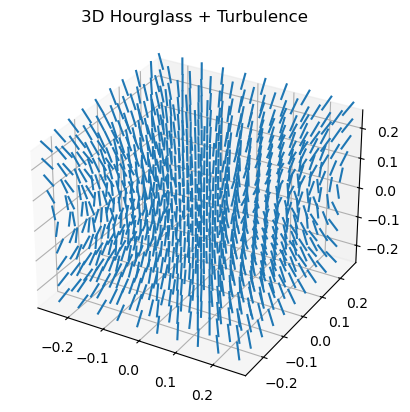

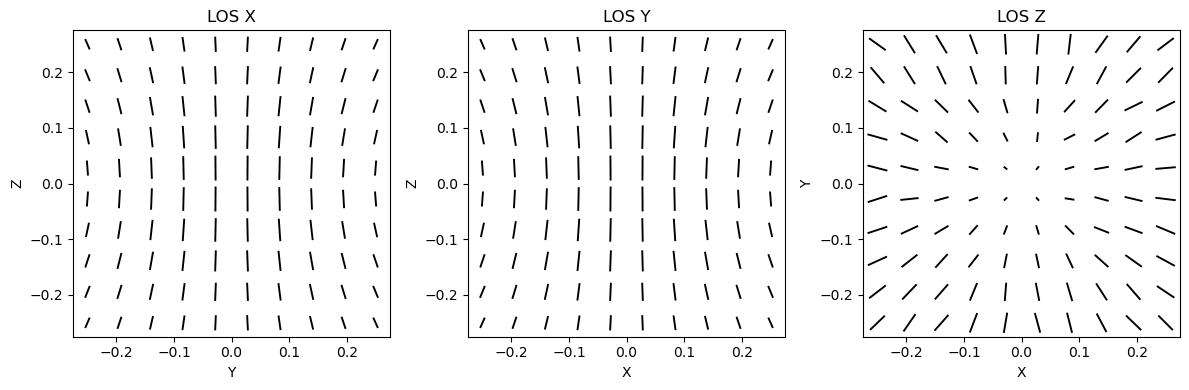

In [3]:
P,PHI,COS = hourglass_mach_test(M_A=0.1, g_size=10, iaxis=2, plotting=True)

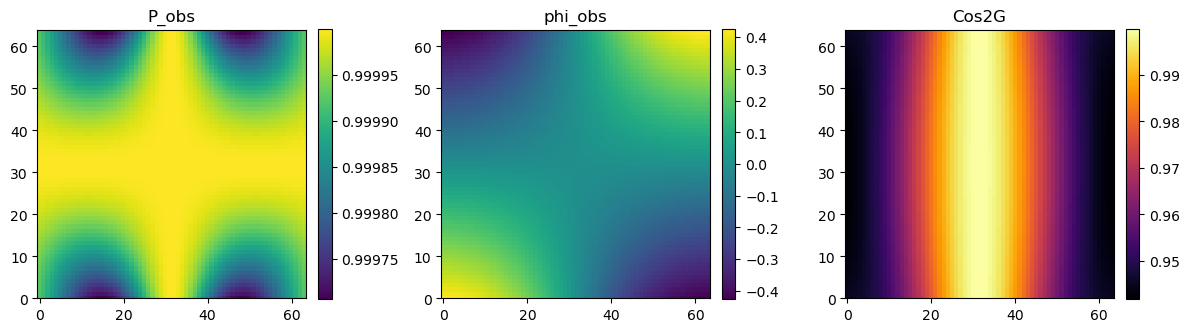

In [5]:
gsize = 64
P,PHI,COS = hourglass_mach_test(M_A=0, g_size=gsize, iaxis=0, plotting=False)

fig, axs = plt.subplots(1,3,figsize=(12,4))

im0 = axs[0].imshow(P, cmap='viridis')
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
axs[0].set_title('P_obs')
axs[0].set_ylim(0,gsize)

im1 = axs[1].imshow(PHI, cmap='viridis')
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
axs[1].set_title('phi_obs')
axs[1].set_ylim(0,gsize)

im2 = axs[2].imshow(COS, cmap='inferno')
plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
axs[2].set_title('Cos2G')
axs[2].set_ylim(0,gsize)

plt.tight_layout()

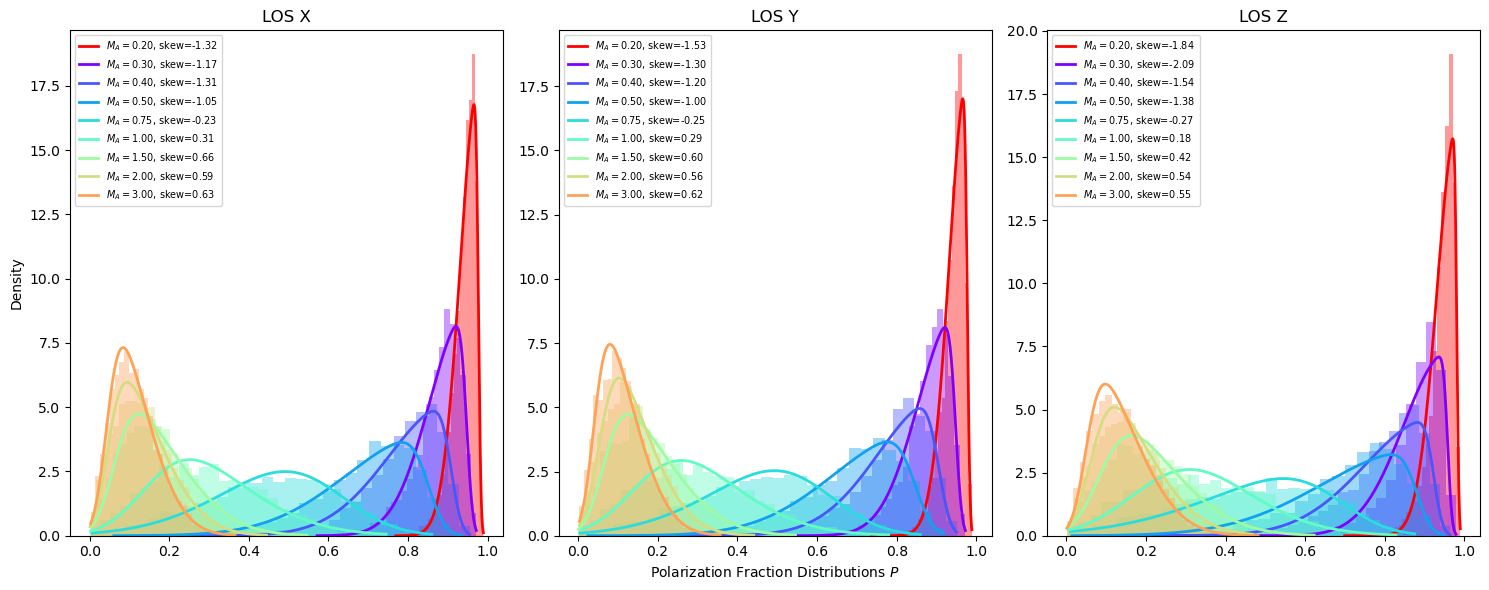

In [7]:
from scipy.stats import skew, skewnorm
# mach_vals = [0,0.01,0.02,0.05]
mach_vals = [0.2,0.3, 0.4, 0.5,0.75,1,1.5,2,3]
color = plt.cm.rainbow(np.linspace(0,1,len(mach_vals)+1))

fig, axes = plt.subplots(1,3,figsize=(15,6))

for nax in range(3):
    for imach in mach_vals:

        # simulate
        P, PHI, COS = hourglass_mach_test(M_A=imach, g_size=64, iaxis=nax, plotting=False)

        # flatten & clip to >0
        Pflat = P.flatten()
        Pflat = Pflat[Pflat > 0]

        # --- compute raw skewness ---
        skew_val = skew(Pflat, bias=False)

        # --- fit skewnormal distribution ---
        # skewnorm.fit returns (a, loc, scale)
        a, loc, scale = skewnorm.fit(Pflat)

        # build PDF for plotting
        x = np.linspace(Pflat.min(), Pflat.max(), 300)
        pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

        # --- histogram ---
        axes[nax].hist(Pflat, bins=30, density=True, alpha=0.4, color = color[mach_vals.index(imach)-1])

        # plt.hist(Pflat, bins=30, density=True, alpha=0.4, color = color[mach_vals.index(imach)-1])

        # --- overlay skewnormal fit ---
        axes[nax].plot(x, pdf_skew, lw=2, label=rf"$M_A={imach:.2f}$, skew={skew_val:.2f}", color=color[mach_vals.index(imach)-1])

    axes[nax].legend(fontsize=7)

axes[1].set_xlabel("Polarization Fraction Distributions $P$")
axes[0].set_ylabel("Density")
axes[0].set_title('LOS X')
axes[1].set_title('LOS Y')
axes[2].set_title('LOS Z')
# axes[0].yscale("log")
# axes[0].set_ylim(0,2000)
# axes[1].set_ylim(0,6000)
# axes[2].set_ylim(0,1e4)
# plt.title('Uniform Field: Polarization Distributions for Varying Mach #')
plt.tight_layout()
plt.show()


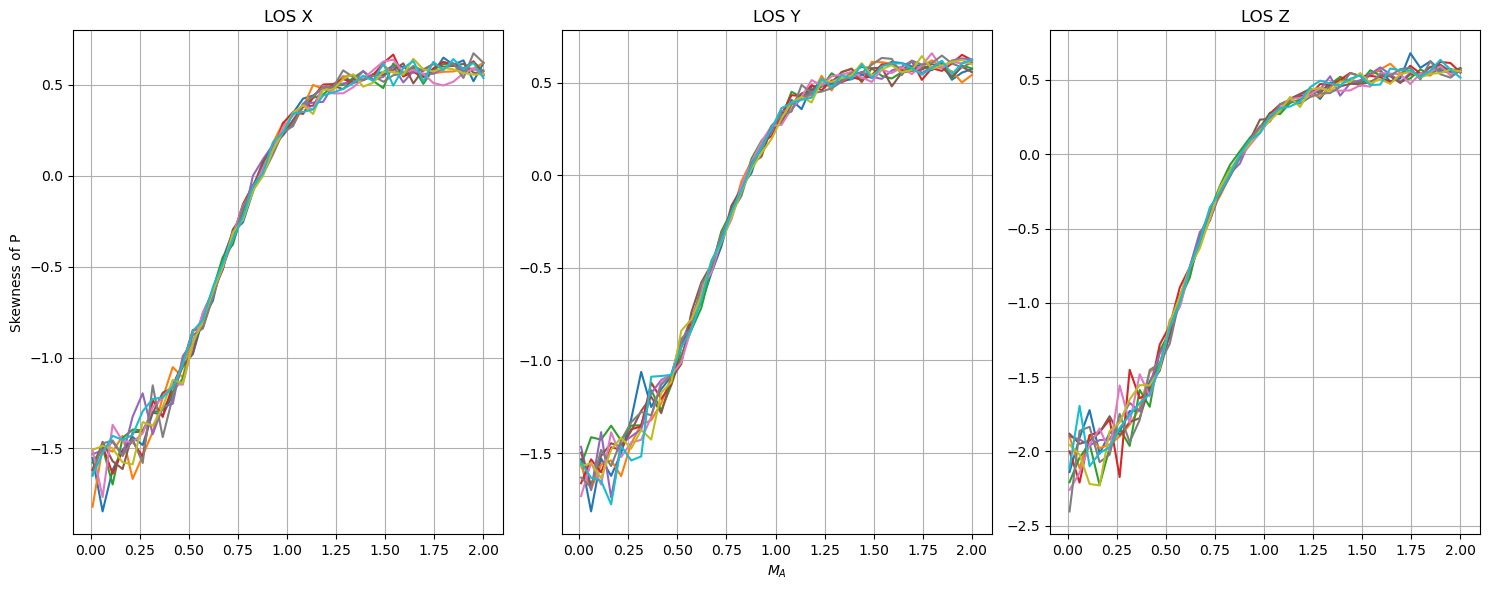

In [154]:
n = 10
fig, axes = plt.subplots(1,3,figsize=(15,6))
mach_vals = np.linspace(0.01,2,40)

for nax in range(3):
    for i in range(n):
        skews = []
        for imach in mach_vals:
            P, PHI, COS = hourglass_mach_test(M_A=imach, g_size=64, iaxis=nax, plotting=False)
            skews.append(skew(P.flatten(), bias=False))
        axes[nax].plot(mach_vals, skews, linestyle='-')

axes[1].set_xlabel(r"$M_A$")
axes[0].set_ylabel("Skewness of P")

axes[0].set_title('LOS X')
axes[1].set_title('LOS Y')
axes[2].set_title('LOS Z')

axes[0].grid()
axes[1].grid()
axes[2].grid()
plt.tight_layout()
plt.show()


In [1]:
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# # draw vectors (normalize to show field direction clearly)
# ax.quiver(X, Y, Z3D, bx_cart, by_cart, bz_cart, length=0.1, normalize=True, 
#                 arrow_length_ratio=0, color='dodgerblue')
# ax.set_xlabel('Bx')
# ax.set_ylabel('By')
# ax.set_zlabel('Bz')
# ax.set_title('Input Hourglass Field')
# plt.show()

In [14]:


# # ===============================
# # user parameters
# # ===============================
# n = 8                      # grid resolution
# L = 0.5                     # box half-size
# B0 = 1.0
# I0 = 1.0

# # LOS choice: 0=x, 1=y, 2=z
# iaxis = 2

# # Turbulence
# turb_sigma = 0.25
# corr_r = 0.9

# # ===============================
# # establish cartesian grid
# # ===============================
# x = np.linspace(-L, L, n)
# y = np.linspace(-L, L, n)
# z = np.linspace(-L, L, n)
# X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
# R = np.sqrt(X**2 + Y**2)

# # ===============================
# # hourglass morphology
# # ===============================
# alpha = 4.0     # pinch strength of hourglass shape
# beta  = 2.0     # vertical taper

# Br = -alpha * R * Z * np.exp(-beta * Z**2)
# Bz = 1.0 + alpha * np.exp(-beta * Z**2)

# # Convert cylindrical to cartesian
# Bx = Br * X / (R + 1e-12) # 1e-12 to avoid division by zero
# By = Br * Y / (R + 1e-12)


In [15]:
# # ===============================
# # add turbulent perturbations
# # ===============================
# delta_theta = np.zeros((n, n, n))

# # axes orthogonal to LOS
# axes = [0, 1, 2]
# axes.remove(iaxis)
# i1, i2 = axes

# for i in range(n):
#     for j in range(n):
#         val = np.random.normal(scale=turb_sigma)
#         for k in range(n):
#             idx = [0, 0, 0]
#             idx[iaxis] = k
#             idx[i1] = i
#             idx[i2] = j
#             delta_theta[tuple(idx)] = val
#             val = corr_r * val + np.random.normal(scale=turb_sigma * np.sqrt(1 - corr_r**2))

# # perturb POS components
# if iaxis == 0:      # LOS = x -- POS = y,z
#     By_p =  By*np.cos(delta_theta) - Bz*np.sin(delta_theta)
#     Bz_p =  By*np.sin(delta_theta) + Bz*np.cos(delta_theta)
#     Bx_p =  Bx
# elif iaxis == 1:    # LOS = y -- POS = x,z
#     Bx_p =  Bx*np.cos(delta_theta) - Bz*np.sin(delta_theta)
#     Bz_p =  Bx*np.sin(delta_theta) + Bz*np.cos(delta_theta)
#     By_p =  By
# else:               # LOS = z -- POS = x,y
#     Bx_p =  Bx*np.cos(delta_theta) - By*np.sin(delta_theta)
#     By_p =  Bx*np.sin(delta_theta) + By*np.cos(delta_theta)
#     Bz_p =  Bz


In [16]:
# # ===============================
# # calculate stokes parameters
# # ===============================
# Bperp2 = Bx_p**2 + By_p**2
# Btot2  = Bperp2 + Bz_p**2

# cos2g = Bperp2 / (Btot2 + 1e-12)

# # two ways of calculating q and u, one with Bz, one with cos2g, but result is the same:

# # q = (By_p**2 - Bx_p**2) / (Bperp2 + 1e-12) * cos2g
# # u = (2 * Bx_p * By_p) / (Bperp2 + 1e-12) * cos2g

# q = (By_p**2 - Bx_p**2) / Btot2
# u = (2 * Bx_p * By_p) / Btot2

# Q = I0 * q
# U = I0 * u



In [17]:
# # ===============================
# # integrate along LOS, calculate observables
# # ===============================
# Q_obs = Q.sum(axis=iaxis)
# U_obs = U.sum(axis=iaxis)
# I_obs = I0 * n

# P_obs   = np.sqrt(Q_obs**2 + U_obs**2) / I_obs
# phi_obs = 0.5 * np.arctan2(U_obs, Q_obs)
# cos2g_LOS = (I0*cos2g).sum(axis=iaxis)/I0


In [26]:
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# # draw vectors (normalize to show field direction clearly)
# ax.quiver(X, Y, Z, Bx_p, By_p, Bz_p, length=0.08, normalize=True, 
#         arrow_length_ratio=0.2, color='dodgerblue')
# ax.set_xlabel('Bx')
# ax.set_ylabel('By')
# ax.set_zlabel('Bz')
# ax.set_title('Input Hourglass Field')
# # make axes aspect ratio match data extents so z isn't visually squashed
# ax.set_box_aspect((np.ptp(x), np.ptp(y), np.ptp(z)))
# plt.show()

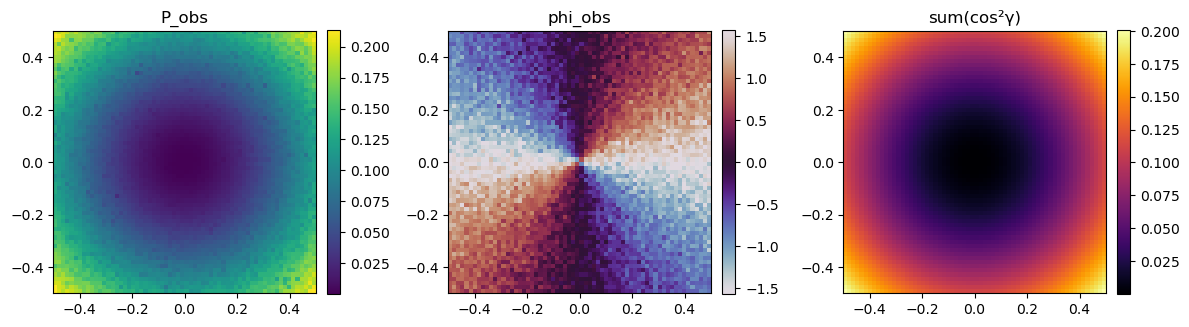

In [ ]:
# # ===============================
# # plot observables to compare and check
# # ===============================
# fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# extent = [-L, L, -L, L]

# im0 = axs[0].imshow(P_obs.T, origin="lower", extent=extent, cmap="viridis")
# plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
# axs[0].set_title("P_obs")

# im1 = axs[1].imshow(phi_obs.T, origin="lower", extent=extent, cmap="twilight")
# plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
# axs[1].set_title("phi_obs")

# im2 = axs[2].imshow(cos2g[:,:,0], origin="lower",
#                     extent=extent, cmap="inferno")
# plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
# axs[2].set_title("sum(cos²γ)")

# plt.tight_layout()
# plt.show()


### For cos2g vs. P:
- with turbulence, expect vertical scatter
- without turbulence, expect tight correlation

Text(0.5, 1.0, 'LOS-Summed cos²γ vs P')

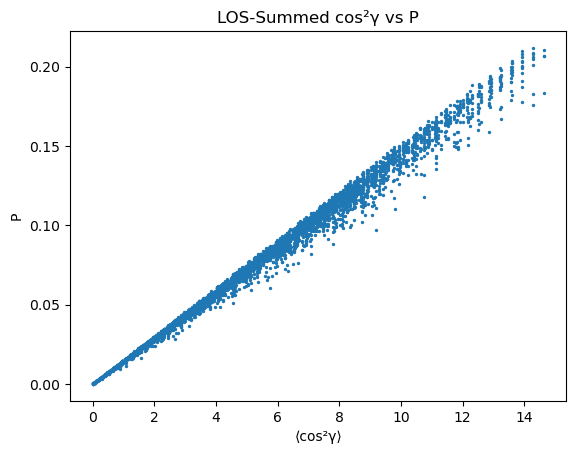

In [ ]:
# # ===============================
# # plot cos2g vs P
# # ===============================
# plt.scatter(cos2g_LOS.flatten(), P_obs.flatten(), s=2, label='cos2g_LOS')
# plt.xlabel("⟨cos²γ⟩")
# plt.ylabel("P")
# plt.title('LOS-Summed cos²γ vs P')


## Now test for varying turbulence

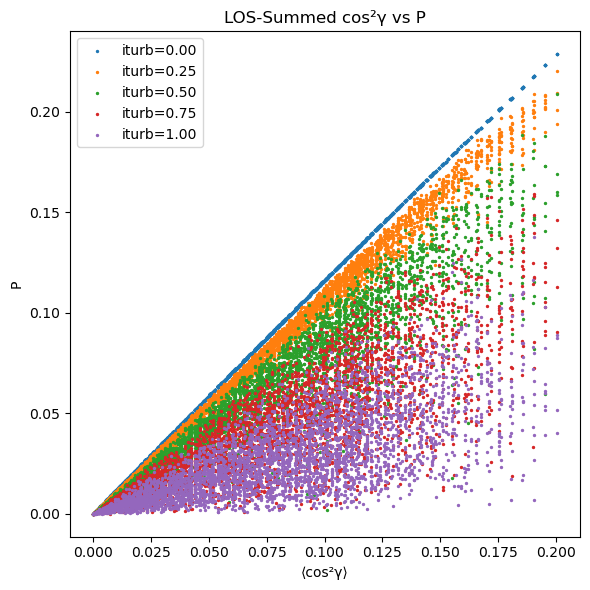

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# def hourglass_turb_test(turb):
#     # ===============================
#     # USER PARAMETERS
#     # ===============================
#     n = 64                      # grid resolution
#     L = 0.5                     # box half-size
#     B0 = 1.0
#     I0 = 1.0

#     # LOS choice: 0=x, 1=y, 2=z
#     iaxis = 2

#     # Turbulence
#     turb_sigma = turb
#     corr_r = 0.9

#     # ===============================
#     # CARTESIAN GRID
#     # ===============================
#     x = np.linspace(-L, L, n)
#     y = np.linspace(-L, L, n)
#     z = np.linspace(-L, L, n)
#     X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

#     R = np.sqrt(X**2 + Y**2)

#     # ===============================
#     # HOURGLASS FIELD (TOY MODEL)
#     # ===============================
#     alpha = 4.0     # pinch strength
#     beta  = 2.0     # vertical taper

#     Br = alpha * R * np.exp(-beta * Z**2)
#     Bz = 1.0 + alpha * np.exp(-beta * Z**2)

#     # Convert cylindrical → Cartesian
#     Bx = Br * X / (R + 1e-12)
#     By = Br * Y / (R + 1e-12)

#     # ===============================
#     # TURBULENCE (ROTATE POS FIELD)
#     # ===============================
#     delta_theta = np.zeros((n, n, n))

#     # axes orthogonal to LOS
#     axes = [0, 1, 2]
#     axes.remove(iaxis)
#     i1, i2 = axes

#     for i in range(n):
#         for j in range(n):
#             val = np.random.normal(scale=turb_sigma)
#             for k in range(n):
#                 idx = [0, 0, 0]
#                 idx[iaxis] = k
#                 idx[i1] = i
#                 idx[i2] = j
#                 delta_theta[tuple(idx)] = val
#                 val = corr_r * val + np.random.normal(
#                     scale=turb_sigma * np.sqrt(1 - corr_r**2)
#                 )

#     # Rotate POS components
#     if iaxis == 0:      # LOS = x → POS = y,z
#         By_p =  By*np.cos(delta_theta) - Bz*np.sin(delta_theta)
#         Bz_p =  By*np.sin(delta_theta) + Bz*np.cos(delta_theta)
#         Bx_p =  Bx
#     elif iaxis == 1:    # LOS = y → POS = x,z
#         Bx_p =  Bx*np.cos(delta_theta) - Bz*np.sin(delta_theta)
#         Bz_p =  Bx*np.sin(delta_theta) + Bz*np.cos(delta_theta)
#         By_p =  By
#     else:               # LOS = z → POS = x,y
#         Bx_p =  Bx*np.cos(delta_theta) - By*np.sin(delta_theta)
#         By_p =  Bx*np.sin(delta_theta) + By*np.cos(delta_theta)
#         Bz_p =  Bz

#     # ===============================
#     # STOKES PARAMETERS
#     # ===============================
#     Bperp2 = Bx_p**2 + By_p**2
#     Btot2  = Bperp2 + Bz_p**2

#     cos2g = Bperp2 / (Btot2 + 1e-12)

#     q = (By_p**2 - Bx_p**2) / (Bperp2 + 1e-12) * cos2g
#     u = (2 * Bx_p * By_p) / (Bperp2 + 1e-12) * cos2g

#     Q = I0 * q
#     U = I0 * u

#     # ===============================
#     # LOS INTEGRATION
#     # ===============================
#     Q_obs = Q.sum(axis=iaxis)
#     U_obs = U.sum(axis=iaxis)
#     I_obs = I0 * n

#     P_obs   = np.sqrt(Q_obs**2 + U_obs**2) / I_obs
#     phi_obs = 0.5 * np.arctan2(U_obs, Q_obs)
#     # cos2g_LOS = (I0*cos2g).sum(axis=iaxis)/I0
#     cos2g_LOS = cos2g[:,:,0] # take first slice of cos2g since it's the same along LOS

#     P_complex   = Q_obs + 1j * U_obs
#     P_max       = I0*cos2g_LOS
#     P_coherence = np.abs(P_complex) / (P_max + 1e-12)

#     # ===============================
#     # PLOTS
#     # ===============================

#     plt.scatter(cos2g_LOS.flatten(), P_obs.flatten(), s=2, label='iturb={:.2f}'.format(turb))
#     plt.xlabel("⟨cos²γ⟩")
#     plt.ylabel("P")
#     plt.title('LOS-Summed cos²γ vs P')

# plt.figure(figsize=(6,6))
# for iturb in np.linspace(0, 1, 5):
#     hourglass_turb_test(turb=iturb)
# plt.legend()
# plt.tight_layout()


In [ ]:
# P_complex   = Q_obs + 1j * U_obs
# P_max       = I0*cos2g_LOS
# P_coherence = np.abs(P_complex) / (P_max + 1e-12)

# fig, axs = plt.subplots(2, 2, figsize=(5, 5))

# axs[0,0].imshow(P_obs.T, origin="lower")
# axs[0,0].set_title("Observed P")

# axs[0,1].imshow(cos2g_LOS.T, origin="lower")
# axs[0,1].set_title("⟨cos²γ⟩")

# axs[1,0].imshow(P_coherence.T, origin="lower")
# axs[1,0].set_title("Coherence")

# axs[1,1].imshow((P_obs / cos2g_LOS).T, origin="lower")
# axs[1,1].set_title("P / ⟨cos²γ⟩")

# plt.tight_layout()


# phi = 0.5 * np.arctan2(U, Q)

# phi_mean = np.mean(phi, axis=iaxis)
# phi_disp = np.sqrt(np.mean((phi - phi_mean[...,None])**2, axis=iaxis))

# plt.scatter(phi_disp.flatten(), P_coherence.flatten(), s=2)
# plt.xlabel(r"Dispersion in $\phi$")
# plt.ylabel("Coherence in P")
